# 손(Hand) 검출 모델 학습 — YOLO26 / Ultralytics

Roboflow에서 라벨링한 100장 데이터셋으로 **좌수 X-ray의 손 영역 bbox 검출기**를 학습하고,
Bone Age 파이프라인에서 쓸 **자동 크롭 함수**까지 만듭니다.

| 파트 | 내용 |
|---|---|
| Part 0 | 환경 점검 (GPU / PyTorch / Ultralytics) |
| Part 1 | 경로 설정 + 한글경로 → ASCII 경로 복사 |
| Part 2 | 데이터셋 무결성 검사 (라벨/박스 통계) |
| Part 3 | `data.yaml` 재생성 (절대경로, 클래스명 ASCII화) |
| Part 4 | 샘플 시각화 (라벨 눈으로 검증) |
| Part 5 | **하이퍼파라미터** ← 여기만 고쳐서 재실행 |
| Part 6 | 학습 |
| Part 7 | 검증 (mAP) + 학습 곡선 |
| Part 8 | 크롭 함수 정의 (QC 플래그 포함) |
| Part 9 | test 셋 크롭 시각 검증 |
| Part 10 | RSNA 전체 데이터 배치 크롭 + QC CSV |
| Part 11 | 실패 사례 추출 → 추가 라벨링 (Active Learning) |

**설계 원칙**
- 기존 `_adv_select_hand()`(Otsu + connected components) 휴리스틱을 대체합니다. 전완만 잡히거나 바깥 밝은 프레임을 손으로 오인하던 무음 버그를 구조적으로 제거합니다.
- 모든 산출물은 `OUTPUT_DIR` 한 곳에만 저장합니다.
- 이미지 I/O는 전부 `np.fromfile + cv2.imdecode`(`imread_u`) 로 처리해 한글 경로 무음 실패를 막습니다.


## Part 0. 환경 점검

In [1]:
# 최초 1회만 실행 (설치되어 있으면 건너뛰세요)
# RTX 5060(Blackwell, sm_120)은 cu128 이상 휠이 필요합니다.
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
# pip install ultralytics opencv-python pandas matplotlib tqdm

import sys, platform, subprocess

try:
    import torch, ultralytics
except ImportError as e:
    raise SystemExit(f"[설치 필요] {e}\n위 주석의 pip 명령을 먼저 실행하세요.")

print("Python      :", sys.version.split()[0], "|", platform.platform())
print("PyTorch     :", torch.__version__, "| CUDA build:", torch.version.cuda)
print("Ultralytics :", ultralytics.__version__)
print("CUDA 사용가능:", torch.cuda.is_available())

if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    print("GPU         :", torch.cuda.get_device_name(0), f"| sm_{cap[0]}{cap[1]}")
    # Blackwell(sm_120) 인데 지원 목록에 없으면 커널 미스매치 → 학습 시 에러
    if f"sm_{cap[0]}{cap[1]}" not in torch.cuda.get_arch_list():
        print("  ⚠ 현재 torch 빌드가 이 GPU 아키텍처를 지원하지 않습니다. cu128 휠로 재설치하세요.")
        print("  지원 아키텍처:", torch.cuda.get_arch_list())
else:
    print("  ⚠ CPU로 학습하면 100장 기준 수십 분~시간 단위가 걸립니다.")


Python      : 3.11.9 | Windows-10-10.0.26200-SP0
PyTorch     : 2.12.0.dev20260408+cu128 | CUDA build: 12.8
Ultralytics : 8.4.86
CUDA 사용가능: True
GPU         : NVIDIA GeForce RTX 5060 Laptop GPU | sm_120


## Part 1. 경로 설정 + ASCII 경로로 복사

**왜 복사하나요?**
`C:\Users\mingd\다운로드\...` 경로에는 한글이 들어 있고 폴더명에 공백/점(`My First Project.yolo26`)이 있습니다.
Ultralytics 내부는 대부분 non-ASCII를 처리하지만, 캐시(`.cache`) 생성·멀티프로세스 워커·서브프로세스 호출 단계에서
간헐적으로 깨집니다. **원본은 그대로 두고 ASCII 경로로 복사**해서 그 위험을 0으로 만듭니다.


In [2]:
from pathlib import Path
import shutil, os

# ─── 원본(Roboflow 압축 해제 위치) ─────────────────────────────
SRC_DIR = Path(r"C:\Users\Win11Pro\Downloads\My First Project.yolo26")

# ─── 작업 루트 (ASCII·공백 없음) ──────────────────────────────
PROJECT_DIR = Path(r"C:\work\hand_det")
DATA_DIR    = PROJECT_DIR / "dataset"     # 복사된 데이터셋
OUTPUT_DIR  = PROJECT_DIR / "runs"        # 모든 산출물(가중치/로그/크롭/QC)
CROP_DIR    = OUTPUT_DIR / "crops"

FORCE_RECOPY = False   # 원본을 다시 라벨링해서 재export 했다면 True

for d in (PROJECT_DIR, OUTPUT_DIR, CROP_DIR):
    d.mkdir(parents=True, exist_ok=True)

def _is_ascii(p) -> bool:
    return str(p).isascii()

assert _is_ascii(PROJECT_DIR), "PROJECT_DIR 에 비ASCII 문자가 있습니다. 경로를 바꾸세요."

if FORCE_RECOPY and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if not DATA_DIR.exists():
    if not SRC_DIR.exists():
        raise FileNotFoundError(f"원본 데이터셋을 찾을 수 없습니다: {SRC_DIR}")
    print(f"복사 중... {SRC_DIR}\n  →  {DATA_DIR}")
    shutil.copytree(SRC_DIR, DATA_DIR)
    print("복사 완료")
else:
    print(f"이미 복사됨 (건너뜀): {DATA_DIR}")

SPLITS = {}
for s in ("train", "valid", "test"):
    ip, lp = DATA_DIR / s / "images", DATA_DIR / s / "labels"
    if ip.exists():
        SPLITS[s] = (ip, lp)

print("\n[스플릿 현황]")
for s, (ip, lp) in SPLITS.items():
    n_img = len([p for p in ip.iterdir() if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".bmp")])
    n_lab = len(list(lp.glob("*.txt"))) if lp.exists() else 0
    print(f"  {s:6s} images={n_img:5d}  labels={n_lab:5d}")


복사 중... C:\Users\Win11Pro\Downloads\My First Project.yolo26
  →  C:\work\hand_det\dataset
복사 완료

[스플릿 현황]
  train  images=   70  labels=   70
  valid  images=   20  labels=   20
  test   images=   10  labels=   10


## Part 2. 데이터셋 무결성 검사

학습 전에 **눈으로 못 보는 문제**를 숫자로 먼저 잡습니다.

| 점검 항목 | 왜 중요한가 |
|---|---|
| 이미지↔라벨 1:1 매칭 | 라벨 없는 이미지는 "객체 없음"으로 학습돼 검출률을 떨어뜨림 |
| 빈 라벨 파일 | 위와 동일. Roboflow에서 라벨 누락 시 발생 |
| 이미지당 박스 수 | 손은 1장에 1개여야 정상. 2개 이상이면 중복 라벨 |
| 박스 면적 비율 | 지나치게 작으면(<10%) 오라벨, 지나치게 크면(>95%) 프레임 통째로 잡은 것 |
| 박스 종횡비 | 손 crop은 세로가 긴 형태(h/w ≈ 1.2~2.0)가 정상 |
| 클래스 id | 단일 클래스면 전부 0 이어야 함 |


In [3]:
import numpy as np, pandas as pd, cv2

IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

def imread_u(path, flags=cv2.IMREAD_COLOR):
    """한글/유니코드 경로 안전 imread (cv2.imread는 Windows에서 무음 실패)"""
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, flags)
    if img is None:
        raise IOError(f"이미지 디코드 실패: {path}")
    return img

def imwrite_u(path, img):
    """한글/유니코드 경로 안전 imwrite"""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix if path.suffix else ".png"
    ok, buf = cv2.imencode(ext, img)
    if not ok:
        raise IOError(f"이미지 인코딩 실패: {path}")
    buf.tofile(str(path))
    return True

rows, problems = [], []

for split, (ip, lp) in SPLITS.items():
    imgs = sorted([p for p in ip.iterdir() if p.suffix.lower() in IMG_EXT])
    for p in imgs:
        lab = lp / (p.stem + ".txt")
        if not lab.exists():
            problems.append((split, p.name, "라벨 파일 없음")); continue
        lines = [l.strip() for l in lab.read_text(encoding="utf-8").splitlines() if l.strip()]
        if not lines:
            problems.append((split, p.name, "빈 라벨(객체 0개)")); continue
        if len(lines) > 1:
            problems.append((split, p.name, f"박스 {len(lines)}개(중복 의심)"))
        h, w = imread_u(p, cv2.IMREAD_GRAYSCALE).shape[:2]
        for ln in lines:
            f = ln.split()
            cid, cx, cy, bw, bh = int(f[0]), *map(float, f[1:5])
            rows.append(dict(split=split, file=p.name, cls=cid, W=w, H=h,
                             cx=cx, cy=cy, bw=bw, bh=bh,
                             area_ratio=bw * bh,
                             aspect=(bh * h) / max(bw * w, 1e-6)))

df = pd.DataFrame(rows)
print(f"총 박스 {len(df)}개 / 이미지 {df.file.nunique()}장\n")
print("클래스 분포:", df.cls.value_counts().to_dict())
print("\n[스플릿별 박스 통계]")
print(df.groupby("split")[["area_ratio", "aspect", "bw", "bh"]]
        .describe().round(3).loc[:, (slice(None), ["mean", "min", "max"])])

# 이상치 후보
odd = df[(df.area_ratio < 0.10) | (df.area_ratio > 0.95) |
         (df.aspect < 0.9) | (df.aspect > 2.6)]
print(f"\n[이상치 후보] {len(odd)}건")
if len(odd):
    display(odd[["split", "file", "area_ratio", "aspect"]].round(3).head(20))

print(f"\n[구조 문제] {len(problems)}건")
for x in problems[:20]:
    print("  ", x)


총 박스 100개 / 이미지 100장

클래스 분포: {0: 100}

[스플릿별 박스 통계]
      area_ratio               aspect                   bw                \
            mean    min    max   mean    min    max   mean    min    max   
split                                                                      
test       0.548  0.286  0.820  1.517  1.287  1.818  0.693  0.445  0.865   
train      0.489  0.139  0.820  1.496  0.904  2.122  0.657  0.318  0.913   
valid      0.560  0.235  0.794  1.397  0.942  1.800  0.731  0.553  0.901   

          bh                
        mean    min    max  
split                       
test   0.774  0.611  0.947  
train  0.724  0.438  0.961  
valid  0.756  0.405  0.947  

[이상치 후보] 0건

[구조 문제] 0건


## Part 3. `data.yaml` 재생성

Roboflow가 만든 `data.yaml`은 상대경로(`../train/images`)라 노트북 실행 위치에 따라 깨집니다.
또 클래스명이 한글(`손`)이면 Ultralytics 결과 플롯의 라벨이 □□□로 깨집니다.
→ **절대경로 + 클래스명 `hand`** 로 새로 씁니다. (원본 파일은 건드리지 않고 별도 파일 생성)


In [4]:
import yaml

DATA_YAML = PROJECT_DIR / "data_hand.yaml"

# 원본 클래스 확인 (참고용)
src_yaml = DATA_DIR / "data.yaml"
if src_yaml.exists():
    print("원본 data.yaml:", yaml.safe_load(src_yaml.read_text(encoding="utf-8")))

cfg = {
    "path":  str(DATA_DIR).replace("\\", "/"),
    "train": "train/images",
    "val":   "valid/images",
    "names": {0: "hand"},          # 한글 '손' → 'hand' (플롯 폰트 깨짐 방지)
}
if "test" in SPLITS:
    cfg["test"] = "test/images"

DATA_YAML.write_text(yaml.safe_dump(cfg, allow_unicode=True, sort_keys=False), encoding="utf-8")
print("\n생성:", DATA_YAML)
print(DATA_YAML.read_text(encoding="utf-8"))


원본 data.yaml: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['hand'], 'roboflow': {'workspace': '-c8b6m', 'project': 'my-first-project-bserm', 'version': 'dataset', 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/-c8b6m/my-first-project-bserm/dataset/dataset'}}

생성: C:\work\hand_det\data_hand.yaml
path: C:/work/hand_det/dataset
train: train/images
val: valid/images
names:
  0: hand
test: test/images



## Part 4. 샘플 시각화 — 라벨을 눈으로 검증

숫자 통계로 안 걸리는 오라벨(손등 절반만, 전완 포함 등)은 결국 눈으로 봐야 잡힙니다.
**Part 2에서 나온 이상치 후보를 우선 확인**하세요.

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\1125455162.py:27: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\1125455162.py:27: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\1125455162.py:27: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\1125455162.py:27: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\1125455162.py:27: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
 

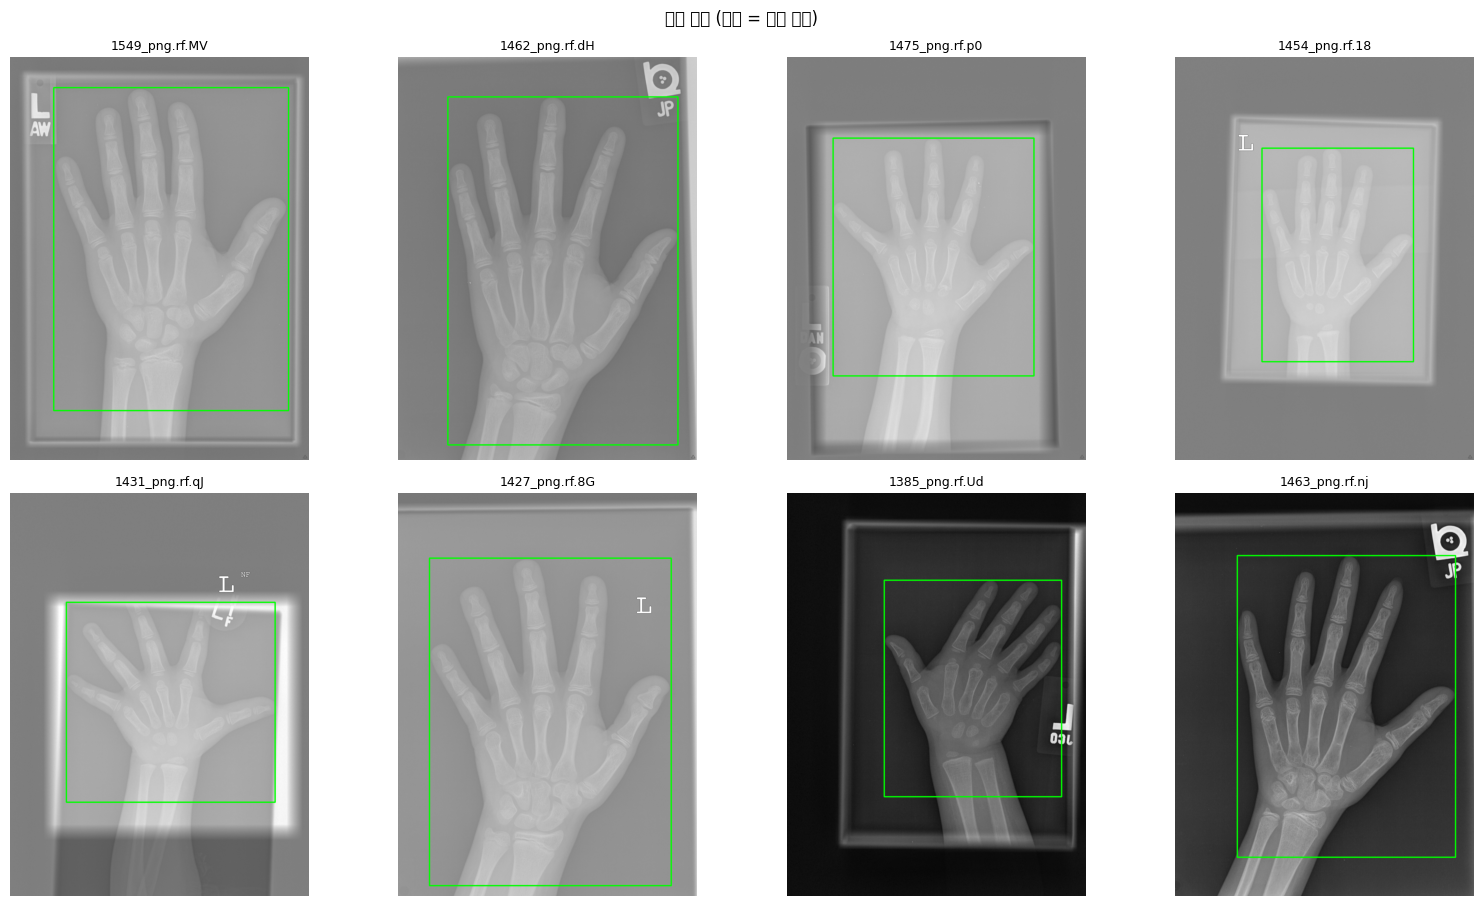

In [5]:
import matplotlib.pyplot as plt

def draw_yolo_label(img_path, lab_path):
    img = imread_u(img_path, cv2.IMREAD_COLOR)
    h, w = img.shape[:2]
    if Path(lab_path).exists():
        for ln in Path(lab_path).read_text(encoding="utf-8").splitlines():
            if not ln.strip():
                continue
            _, cx, cy, bw, bh = map(float, ln.split()[:5])
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), max(2, w // 300))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_grid(pairs, ncols=4, title=""):
    n = len(pairs)
    if n == 0:
        print("표시할 샘플 없음"); return
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.6 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, (ip, lp, cap) in zip(axes, pairs):
        ax.imshow(draw_yolo_label(ip, lp)); ax.set_title(cap, fontsize=9)
    fig.suptitle(title); plt.tight_layout(); plt.show()

ip, lp = SPLITS["train"]
files = sorted([p for p in ip.iterdir() if p.suffix.lower() in IMG_EXT])

rng = np.random.default_rng(42)
pick = rng.choice(len(files), size=min(8, len(files)), replace=False)
show_grid([(files[i], lp / (files[i].stem + ".txt"), files[i].stem[:14]) for i in pick],
          title="랜덤 샘플 (초록 = 라벨 박스)")

# 이상치 후보 우선 확인
if len(odd):
    sub = odd.drop_duplicates("file").head(8)
    pairs = []
    for _, r in sub.iterrows():
        i2, l2 = SPLITS[r.split]
        pairs.append((i2 / r.file, l2 / (Path(r.file).stem + ".txt"),
                      f"{r.file[:12]} a={r.area_ratio:.2f} r={r.aspect:.2f}"))
    show_grid(pairs, title="이상치 후보 — 오라벨인지 확인")


## Part 5. 하이퍼파라미터

**이 셀만 고쳐서 Part 6부터 재실행**하면 됩니다.

| 파라미터 | 값 | 근거 |
|---|---|---|
| `MODEL` | `yolo26n.pt` | 2026-01-14 공개된 최신 세대. NMS-free end-to-end. 단일 클래스·100장에는 nano로 충분 |
| `IMGSZ` | 640 | 손 = 대형 객체. 1024로 올려도 이득 미미, 시간만 2.5배 |
| `EPOCHS` | 150 | 100장 소량 데이터. `patience`로 조기 종료 |
| `BATCH` | 16 | RTX 5060 8GB + imgsz 640 + nano 기준 여유 |
| `SINGLE_CLS` | True | 클래스 1개 확정 → 분류 손실 제거 |
| `HSV_S/H` | 0.0 | X-ray는 그레이스케일. 색상 증강은 무의미한 노이즈 |
| `FLIPLR` | 0.5 | 좌수 전용 데이터지만 검출기 강건성에는 도움. 회귀 모델과 달리 좌우 정보 불필요 |
| `DEGREES` | 7 | 실제 촬영 회전 편차 범위 |
| `MOSAIC` | 1.0 → `close_mosaic=15` | 소량 데이터 다양성 확보, 마지막 15에폭은 끄고 실제 분포로 마무리 |
| `ERASING` | 0.0 | 손 일부를 지우면 박스 경계 학습이 오염됨 |

> 100장은 검출 태스크로는 적지만, **객체가 1개·항상 화면 중앙부·배경 단순**이라 실무상 mAP50 0.99 / mAP50-95 0.85 이상이 기대치입니다. 그 아래면 Part 11로 데이터를 보강하세요.


In [6]:
# ═══════════════════ 하이퍼파라미터 ═══════════════════
MODEL       = "yolo26n.pt"   # 대안: yolo26s.pt(정확도↑), yolo11n.pt(구세대 안정판)
IMGSZ       = 640
EPOCHS      = 150
BATCH       = 16
PATIENCE    = 40             # 개선 없으면 조기 종료
DEVICE      = 0 if torch.cuda.is_available() else "cpu"
WORKERS     = 0              # Windows는 0 권장 (멀티프로세스 로더 이슈 회피)
SEED        = 42
RUN_NAME    = "hand_yolo26n_640"
RESUME      = False          # 중단된 학습 이어서 하려면 True

# 증강 (X-ray 특성 반영)
AUG = dict(
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.30,   # 명암만 흔듦 (촬영 노출 편차 모사)
    degrees=7.0, translate=0.10, scale=0.30, shear=2.0,
    fliplr=0.5, flipud=0.0,
    mosaic=1.0, close_mosaic=15, mixup=0.0, erasing=0.0,
)

# 옵티마이저
OPTIMIZER   = "auto"
LR0, LRF    = 0.01, 0.01
COS_LR      = True
# ══════════════════════════════════════════════════════

print(f"모델={MODEL}  imgsz={IMGSZ}  epochs={EPOCHS}  batch={BATCH}  device={DEVICE}")
print(f"산출물 → {OUTPUT_DIR / RUN_NAME}")


모델=yolo26n.pt  imgsz=640  epochs=150  batch=16  device=0
산출물 → C:\work\hand_det\runs\hand_yolo26n_640


## Part 6. 학습

- 가중치는 `runs/hand_yolo26n_640/weights/` 에 `best.pt`(최고 mAP), `last.pt`(마지막 에폭)로 저장됩니다.
- 중단되면 이 셀에서 `RESUME=True`로 바꾸고 다시 실행하면 `last.pt`에서 이어집니다.
- 100장·150에폭이면 RTX 5060 기준 **대략 10~20분**입니다.

In [7]:
from ultralytics import YOLO
import time

def load_model(name):
    """yolo26 미지원 환경이면 yolo11n로 자동 폴백"""
    try:
        return YOLO(name), name
    except Exception as e:
        print(f"[경고] {name} 로드 실패 → yolo11n.pt 로 폴백\n  사유: {e}")
        return YOLO("yolo11n.pt"), "yolo11n.pt"

model, used_weights = load_model(MODEL)
print("사용 가중치:", used_weights)

t0 = time.time()
results = model.train(
    data=str(DATA_YAML),
    imgsz=IMGSZ, epochs=EPOCHS, batch=BATCH, patience=PATIENCE,
    device=DEVICE, workers=WORKERS, seed=SEED,
    project=str(OUTPUT_DIR), name=RUN_NAME, exist_ok=True, resume=RESUME,
    single_cls=True, cache=True,          # 100장은 통째로 RAM 캐싱 가능
    optimizer=OPTIMIZER, lr0=LR0, lrf=LRF, cos_lr=COS_LR,
    plots=True, val=True, verbose=True,
    **AUG,
)

RUN_DIR  = OUTPUT_DIR / RUN_NAME
BEST_PT  = RUN_DIR / "weights" / "best.pt"
print(f"\n학습 완료 ({(time.time()-t0)/60:.1f}분)")
print("best.pt:", BEST_PT, "| 존재:", BEST_PT.exists())


사용 가중치: yolo26n.pt
New https://pypi.org/project/ultralytics/8.4.108 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\work\hand_det\data_hand.yaml, degrees=7.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.p

## Part 7. 검증 — mAP와 학습 곡선

**판정 기준**

| 지표 | 합격선 | 의미 |
|---|---|---|
| mAP50 | ≥ 0.99 | 손을 "찾는" 능력. 이 태스크에선 거의 1.0이 나와야 정상 |
| mAP50-95 | ≥ 0.85 | 박스 **경계 정밀도**. 크롭 품질을 좌우하는 실질 지표 |
| Recall | = 1.0 | 미검출 = 크롭 실패. 0.99 미만이면 fallback 로직 필수 |

mAP50-95가 0.8 아래라면 박스가 몇 픽셀씩 밀린다는 뜻 → 크롭 마진을 넉넉히 주거나 라벨을 추가하세요.


Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1122.872.8 MB/s, size: 1138.8 KB)
val: Scanning C:\work\hand_det\dataset\valid\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s4.0s
                   all         20         20      0.998          1      0.995      0.925
Speed: 3.0ms preprocess, 20.0ms inference, 0.0ms loss, 0.2ms postprocess per image
[val  ] mAP50=0.9950  mAP50-95=0.9248  P=0.9979  R=1.0000
Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 952.1138.8 MB/s, size: 1292.0 KB)
val: Scanning C:\work\hand_det

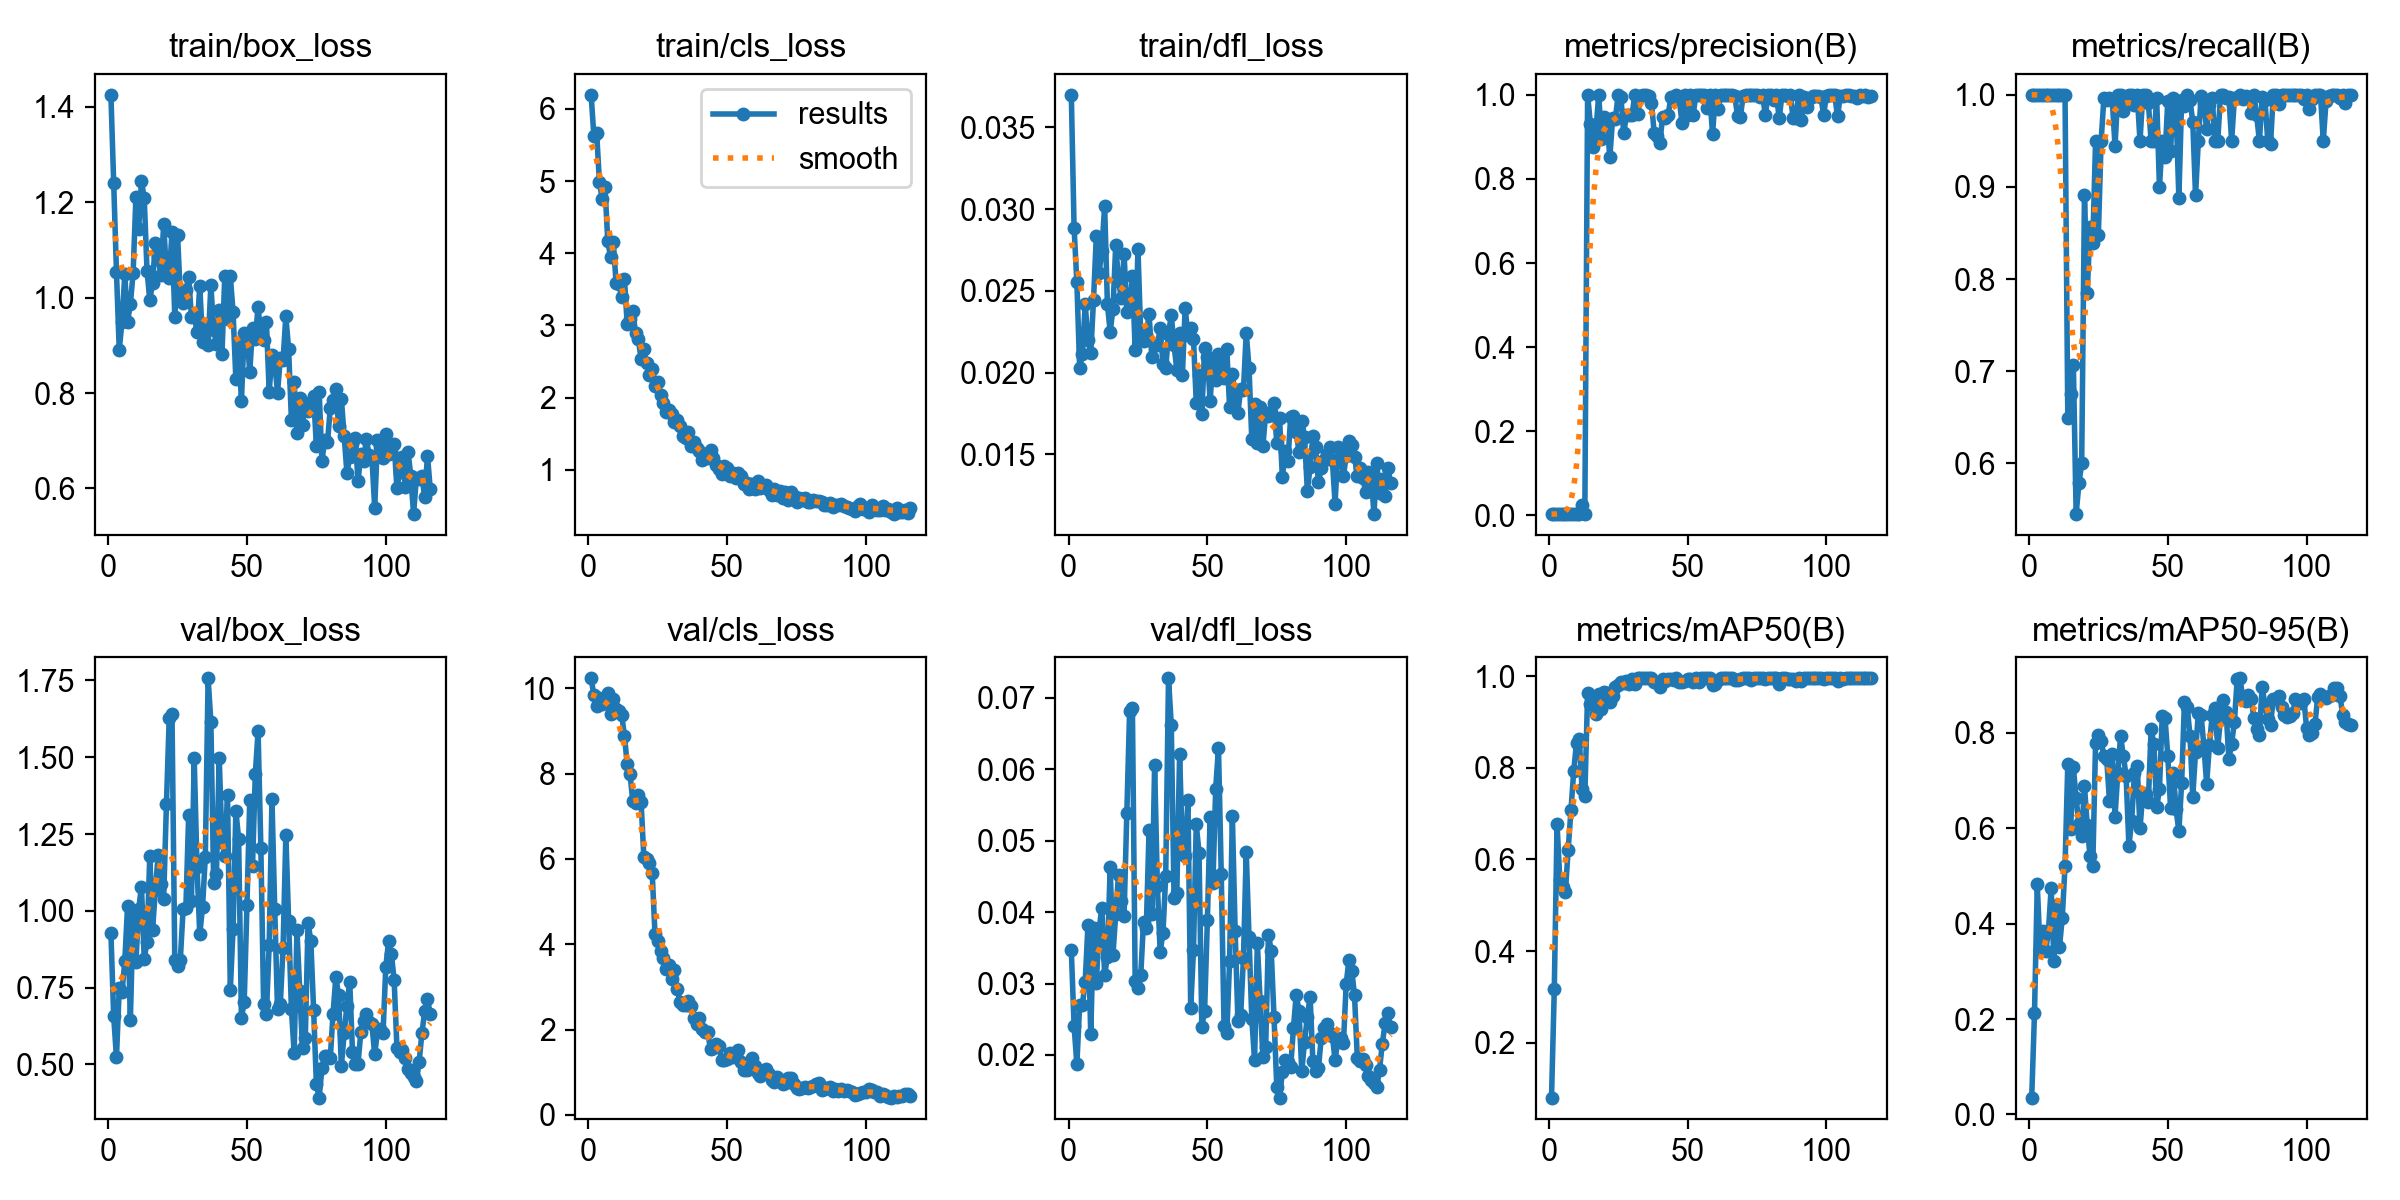


── confusion_matrix_normalized.png ──


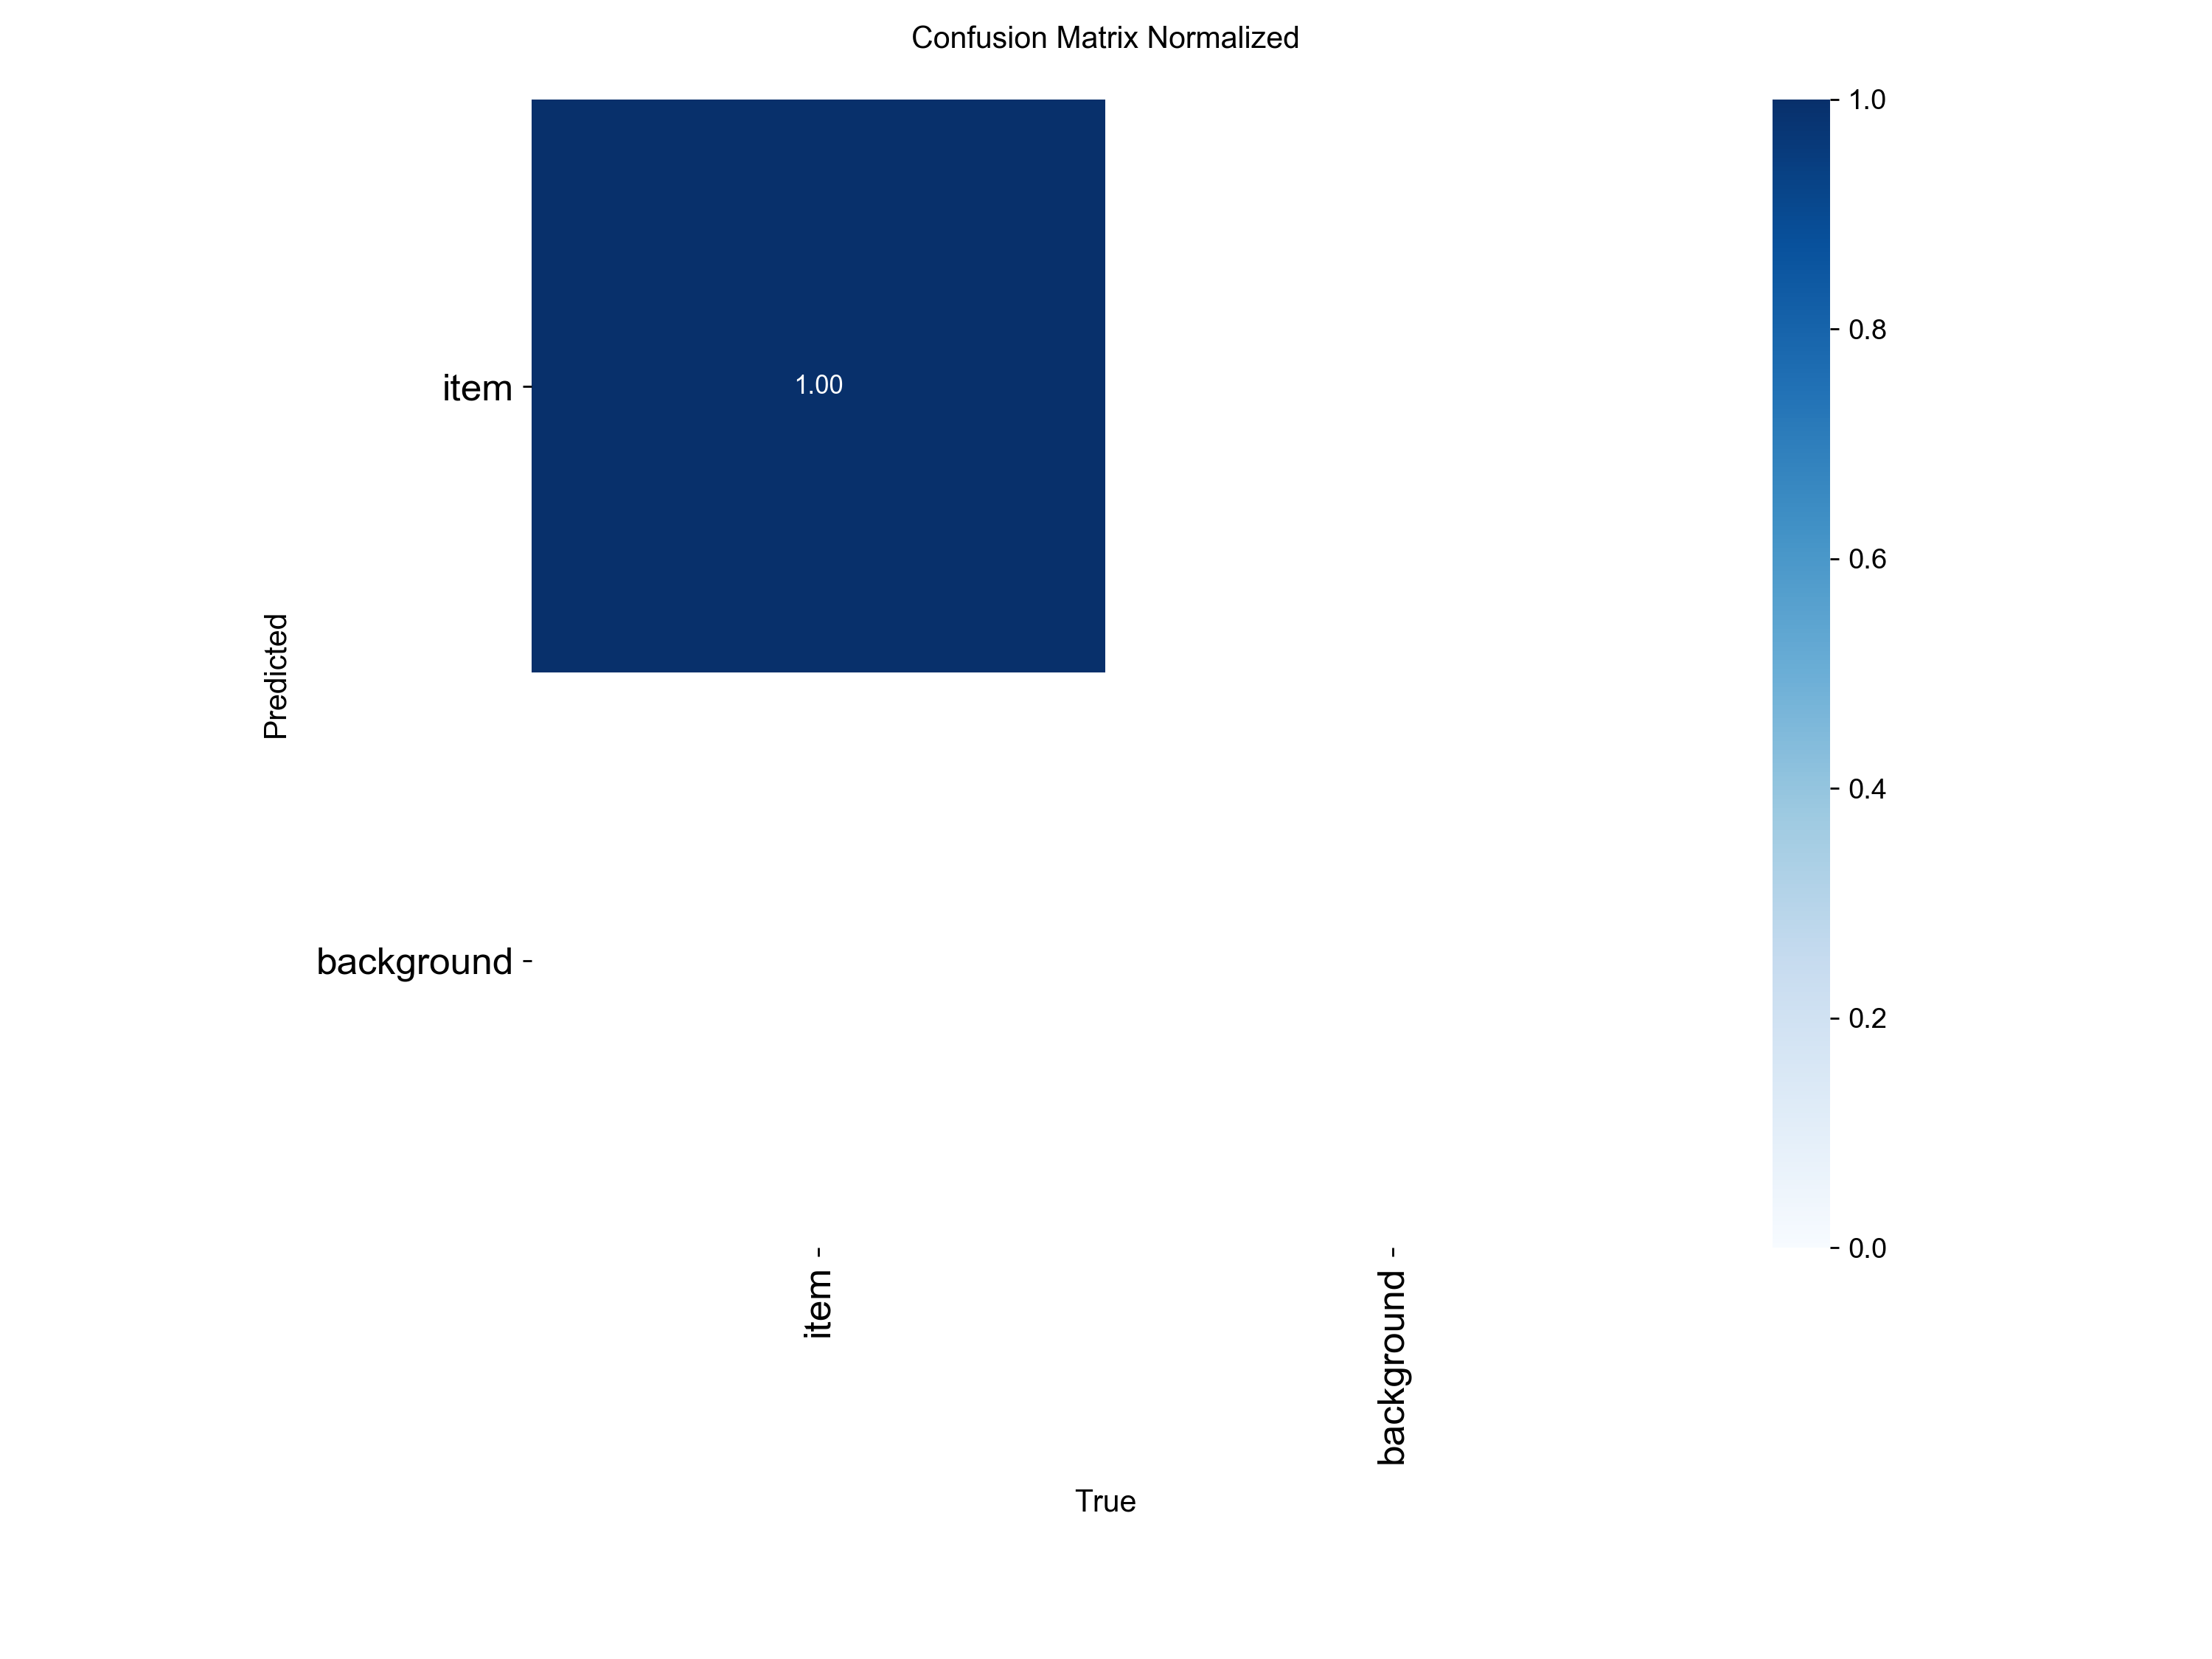


── val_batch0_pred.jpg ──


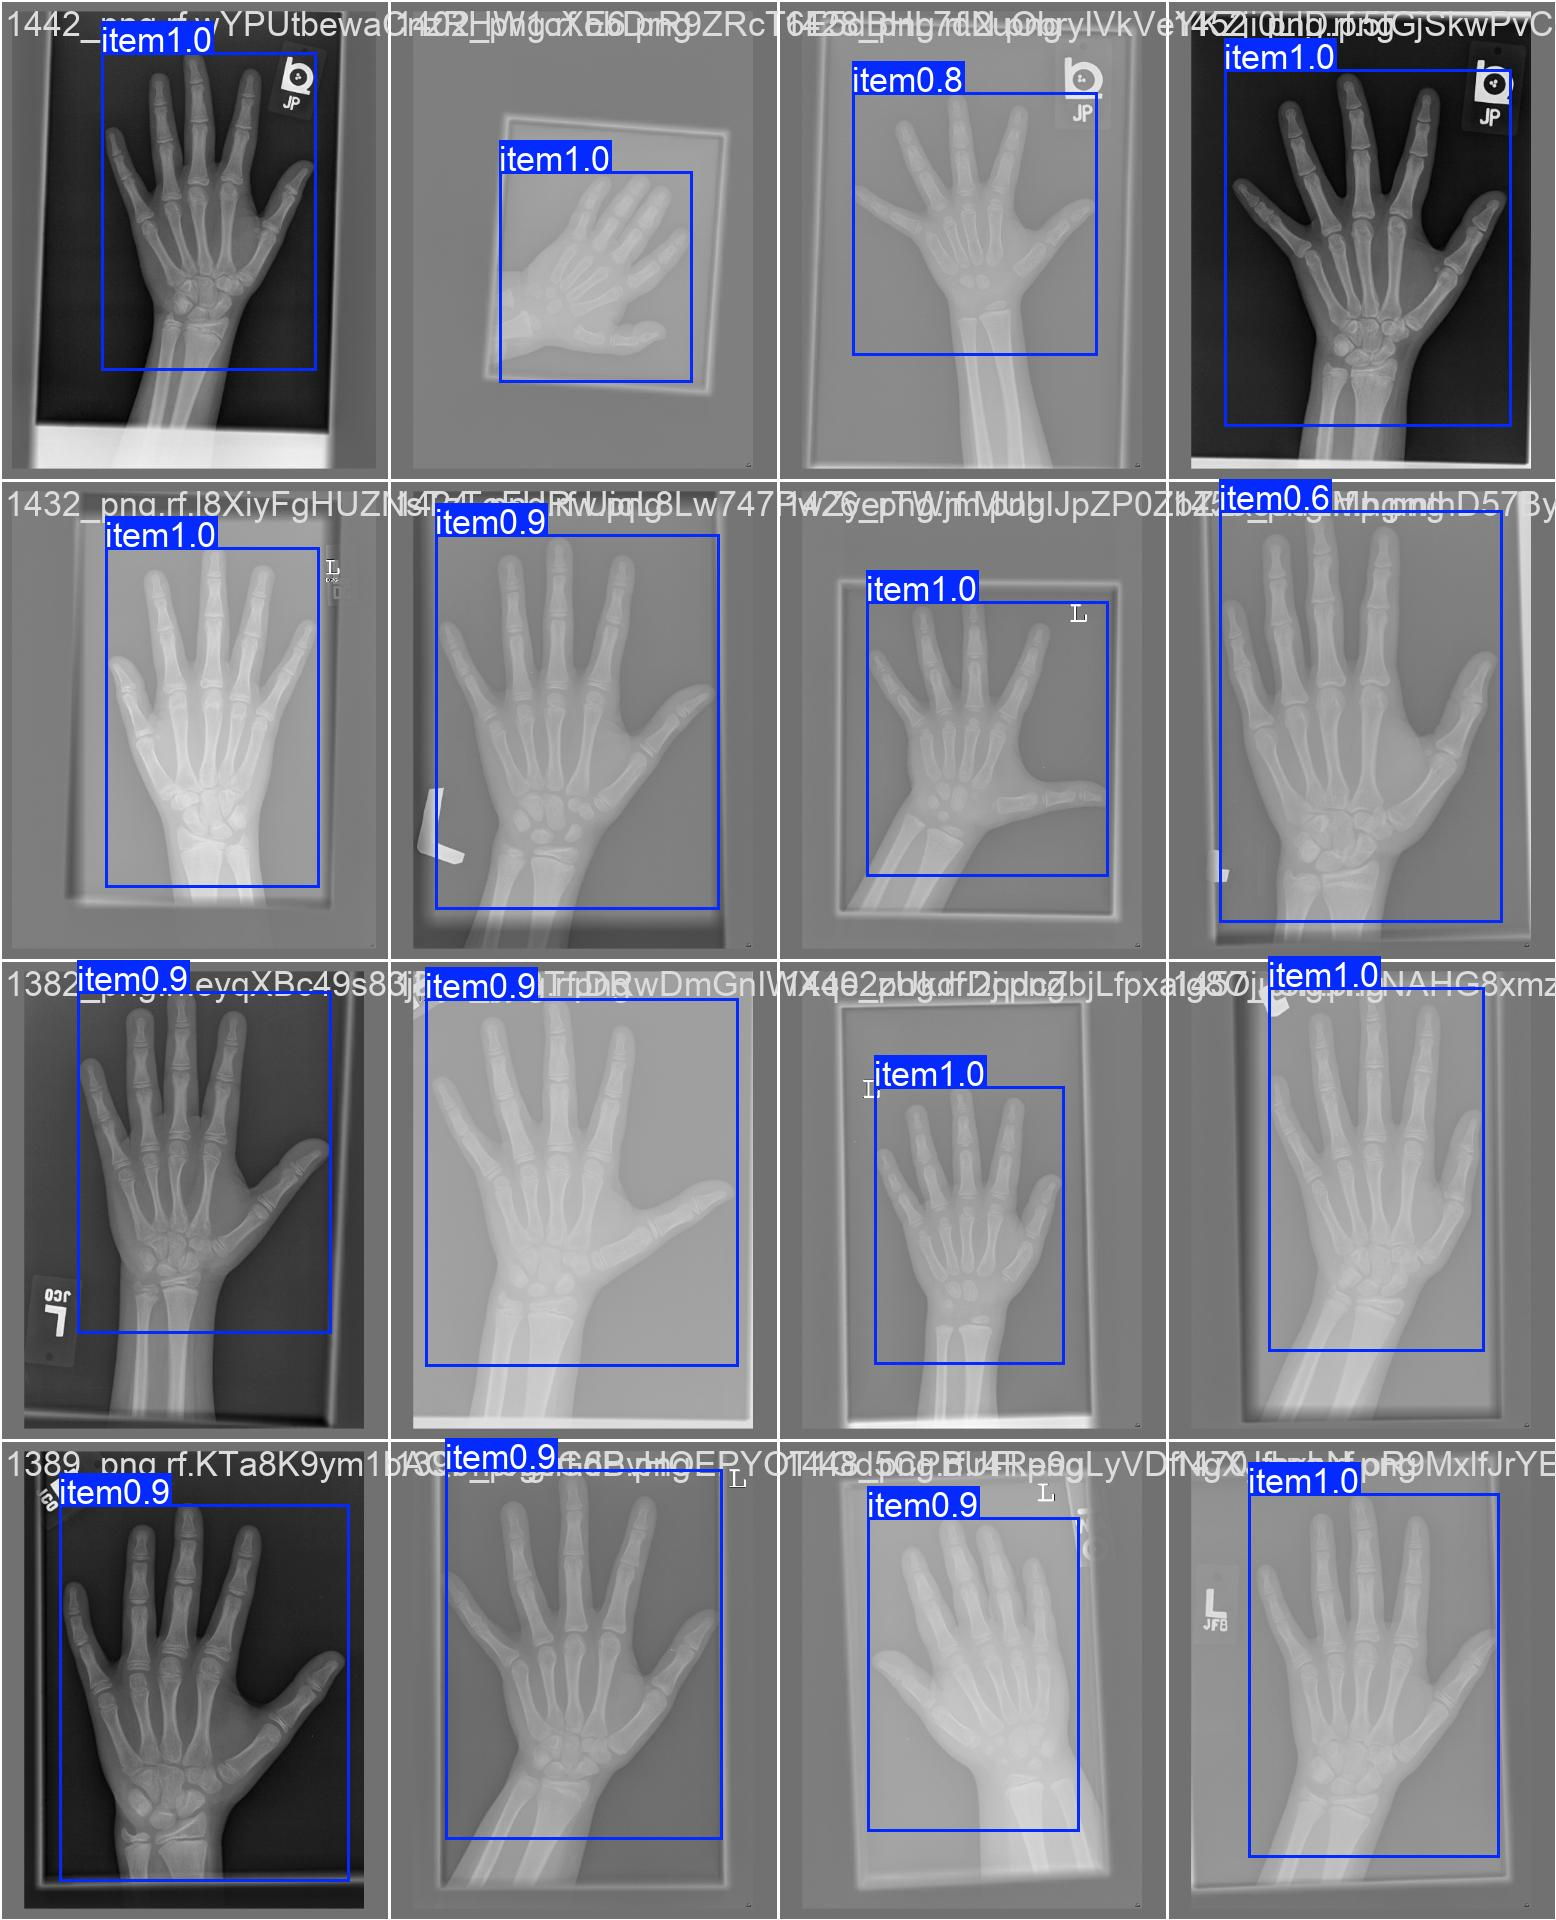


[마지막 5에폭]


,epoch,train/box_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
111,112,0.6195,1.0000,0.9962,0.995,0.8777
112,113,0.6264,0.9970,1.0000,0.995,0.8376
113,114,0.5811,1.0000,0.9910,0.995,0.8227
114,115,0.6688,0.9937,1.0000,0.995,0.8176
115,116,0.5997,0.9972,1.0000,0.995,0.8159


In [8]:
from IPython.display import Image as IPyImage, display

det = YOLO(str(BEST_PT))

for split_key in ["val", "test"]:
    if split_key == "test" and "test" not in SPLITS:
        continue
    m = det.val(data=str(DATA_YAML), split=split_key, imgsz=IMGSZ,
                device=DEVICE, workers=WORKERS,
                project=str(OUTPUT_DIR), name=f"{RUN_NAME}_eval_{split_key}",
                exist_ok=True, plots=False, verbose=False)
    print(f"[{split_key:5s}] mAP50={m.box.map50:.4f}  mAP50-95={m.box.map:.4f}  "
          f"P={m.box.mp:.4f}  R={m.box.mr:.4f}")

# 학습 곡선 / PR 커브
for f in ["results.png", "PR_curve.png", "confusion_matrix_normalized.png", "val_batch0_pred.jpg"]:
    p = RUN_DIR / f
    if p.exists():
        print(f"\n── {f} ──"); display(IPyImage(filename=str(p), width=780))

hist = RUN_DIR / "results.csv"
if hist.exists():
    h = pd.read_csv(hist)
    h.columns = [c.strip() for c in h.columns]
    print("\n[마지막 5에폭]")
    cols = [c for c in ["epoch", "train/box_loss", "metrics/precision(B)",
                        "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"] if c in h.columns]
    display(h[cols].tail().round(4))


## Part 8. 크롭 함수 — QC 플래그 내장

Bone Age 파이프라인에서 실제로 호출할 함수입니다. 설계 포인트:

1. **최고 confidence 박스 1개만** 채택 (손은 1개)
2. **마진 확장** — 박스가 손목/손가락 끝을 몇 픽셀 자르는 걸 방지 (`MARGIN=0.04`)
3. **미검출 fallback** — 검출 실패 시 원본 전체 반환 + `no_det` 플래그. **조용히 넘어가지 않습니다.**
4. **QC 플래그** — 다운스트림에서 필터링/검수할 수 있게 사유를 남김

| 플래그 | 조건 | 의미 |
|---|---|---|
| `no_det` | 박스 0개 | 검출 실패 → 수동 확인 필요 |
| `low_conf` | conf < 0.60 | 신뢰도 낮음 |
| `small_box` | 면적비 < 0.10 | 손이 아닌 조각을 잡았을 가능성 |
| `huge_box` | 면적비 > 0.95 | 프레임 전체를 잡음 (기존 버그와 동일 패턴) |
| `odd_aspect` | h/w < 0.8 또는 > 3.0 | 손 형태가 아님 |
| `touch_border` | 박스가 이미지 가장자리에 접함 | 손이 잘려 촬영됨 |


In [9]:
# ─── 크롭 설정 ───────────────────────────────────────
CONF_TH   = 0.25    # 검출 임계값 (낮게 잡고 QC로 거르는 편이 안전)
MARGIN    = 0.04    # 박스 상하좌우 4% 확장
MIN_AREA  = 0.10
MAX_AREA  = 0.95
ASPECT_LO, ASPECT_HI = 0.8, 3.0
# ────────────────────────────────────────────────────

def detect_hand(model, img_bgr, conf=CONF_TH, imgsz=IMGSZ):
    """최고 confidence 박스 1개 반환 → (xyxy or None, conf)"""
    r = model.predict(img_bgr, conf=conf, imgsz=imgsz, device=DEVICE,
                      verbose=False, max_det=10)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return None, 0.0
    xyxy  = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    i = int(confs.argmax())
    return xyxy[i], float(confs[i])

def crop_hand(model, img_path, margin=MARGIN, conf=CONF_TH):
    """
    이미지 경로 → (크롭 이미지, QC dict)
    검출 실패 시 원본 전체를 반환하되 flags에 'no_det'을 남긴다.
    """
    img = imread_u(img_path, cv2.IMREAD_GRAYSCALE)
    H, W = img.shape[:2]
    bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    box, cf = detect_hand(model, bgr, conf=conf)
    qc = dict(file=Path(img_path).name, W=W, H=H, conf=round(cf, 4), flags="")
    flags = []

    if box is None:
        qc.update(x1=0, y1=0, x2=W, y2=H, area_ratio=1.0, aspect=H / W,
                  flags="no_det")
        return img, qc

    x1, y1, x2, y2 = box
    mw, mh = (x2 - x1) * margin, (y2 - y1) * margin
    x1 = int(max(0, x1 - mw)); y1 = int(max(0, y1 - mh))
    x2 = int(min(W, x2 + mw)); y2 = int(min(H, y2 + mh))

    bw, bh = x2 - x1, y2 - y1
    area_ratio = (bw * bh) / (W * H)
    aspect = bh / max(bw, 1)

    if cf < 0.60:                            flags.append("low_conf")
    if area_ratio < MIN_AREA:                flags.append("small_box")
    if area_ratio > MAX_AREA:                flags.append("huge_box")
    if not (ASPECT_LO <= aspect <= ASPECT_HI): flags.append("odd_aspect")
    if x1 <= 1 or y1 <= 1 or x2 >= W - 1 or y2 >= H - 1: flags.append("touch_border")

    qc.update(x1=x1, y1=y1, x2=x2, y2=y2,
              area_ratio=round(area_ratio, 4), aspect=round(aspect, 3),
              flags="|".join(flags))
    return img[y1:y2, x1:x2], qc

print("crop_hand() 준비 완료")


crop_hand() 준비 완료


## Part 9. test 셋으로 크롭 시각 검증

**여기서 전부 통과해야 Part 10(전체 배치)으로 넘어갑니다.**
원본+박스와 크롭 결과를 나란히 놓고, 손가락 끝·손목 원위부가 잘리지 않았는지 확인하세요.

검증 대상: test (10장)


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\2358990215.py:27: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\2358990215.py:27: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\2358990215.py:27: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\2358990215.py:27: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\2358990215.py:27: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_14400\23

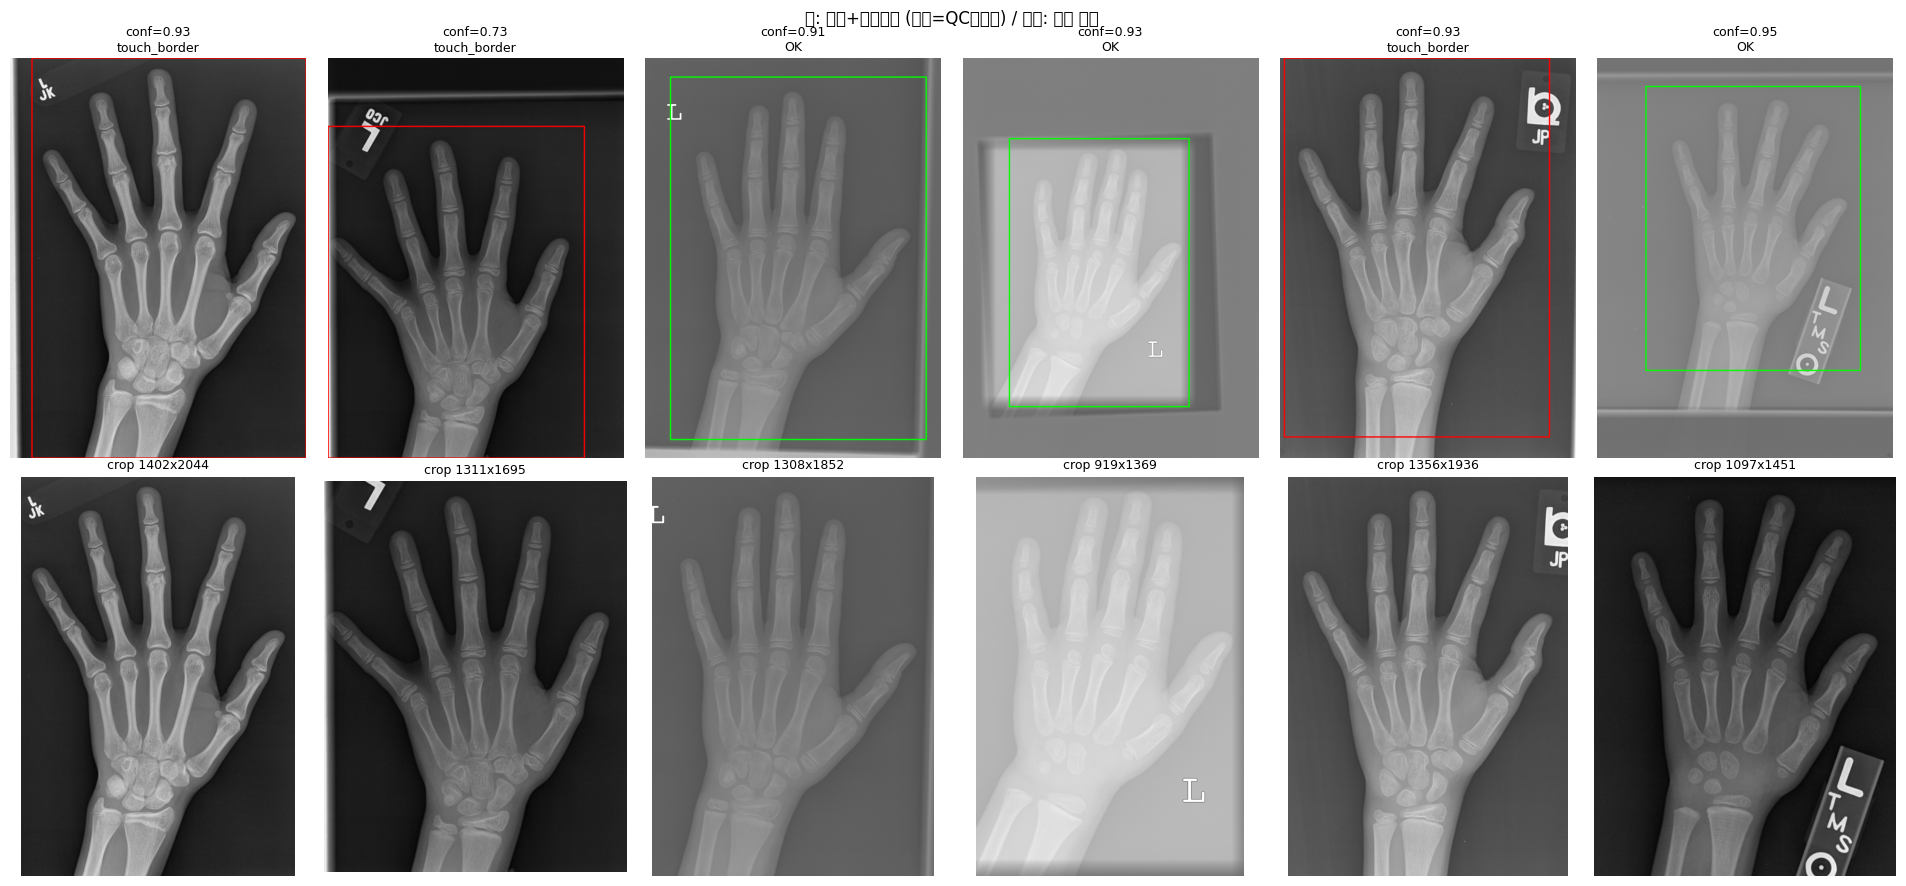

,file,conf,area_ratio,aspect,flags
0,1377_png.rf.zzektzRouuWYpc0iKufG.png,0.9283,0.9260,1.458,touch_border
1,1388_png.rf.QgNlbsg7Cag3eu6x9aad.png,0.7297,0.7181,1.293,touch_border
2,1408_png.rf.KNlWdDD8ukn6J3FjEC2H.png,0.9132,0.7828,1.416,
3,1429_png.rf.dtdC2dvTsUhrgOmWbOef.png,0.9281,0.4065,1.490,
4,1436_png.rf.IDMcn4yI3OZDyYqvvDOR.png,0.9295,0.8483,1.428,touch_border
5,1439_png.rf.hACFSggi46NJzcDtRsLg.png,0.9498,0.5144,1.323,


In [10]:
check_split = "test" if "test" in SPLITS else "valid"
cip, _ = SPLITS[check_split]
cfiles = sorted([p for p in cip.iterdir() if p.suffix.lower() in IMG_EXT])
print(f"검증 대상: {check_split} ({len(cfiles)}장)")

N_SHOW = 6
qc_list = []
fig, axes = plt.subplots(2, N_SHOW, figsize=(3.2 * N_SHOW, 9))

for j, p in enumerate(cfiles[:N_SHOW]):
    crop, qc = crop_hand(det, p)
    qc_list.append(qc)

    orig = imread_u(p, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(orig, cv2.COLOR_GRAY2BGR)
    color = (0, 0, 255) if qc["flags"] else (0, 255, 0)
    cv2.rectangle(vis, (qc["x1"], qc["y1"]), (qc["x2"], qc["y2"]), color, max(2, vis.shape[1] // 250))

    axes[0, j].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0, j].set_title(f"conf={qc['conf']:.2f}\n{qc['flags'] or 'OK'}", fontsize=9)
    axes[1, j].imshow(crop, cmap="gray")
    axes[1, j].set_title(f"crop {crop.shape[1]}x{crop.shape[0]}", fontsize=9)
    for r_ in (0, 1):
        axes[r_, j].axis("off")

plt.suptitle("위: 원본+예측박스 (빨강=QC플래그) / 아래: 크롭 결과")
plt.tight_layout(); plt.show()

display(pd.DataFrame(qc_list)[["file", "conf", "area_ratio", "aspect", "flags"]])


## Part 10. RSNA 전체 데이터 배치 크롭 + QC 로그

Bone Age 학습용 데이터 전체(12,611 / 1,425 / 200)에 적용합니다.

- 결과는 `runs/crops/<split>/` 에 원본 파일명 그대로 저장 → 기존 CSV·DataLoader와 그대로 호환
- QC는 `runs/qc_<split>.csv` 로 남깁니다. **플래그가 붙은 케이스는 반드시 눈으로 확인**하세요.
- 이미 크롭된 파일은 건너뜁니다(`SKIP_EXISTING`). 중단돼도 다시 실행하면 이어서 진행됩니다.


In [11]:
from tqdm.auto import tqdm

# ─── RSNA 원본 경로 (본인 환경에 맞게 수정) ────────────────
RSNA_SPLITS = {
    # "train": Path(r"C:\bone_age\data\train"),
    # "valid": Path(r"C:\bone_age\data\validation"),
    # "test":  Path(r"C:\bone_age\data\test"),
}
SKIP_EXISTING = True
# ─────────────────────────────────────────────────────────

def batch_crop(model, src_dir, dst_dir, tag):
    src_dir, dst_dir = Path(src_dir), Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    files = sorted([p for p in src_dir.rglob("*") if p.suffix.lower() in IMG_EXT])
    recs = []
    for p in tqdm(files, desc=tag):
        out = dst_dir / f"{p.stem}.png"
        if SKIP_EXISTING and out.exists():
            continue
        try:
            crop, qc = crop_hand(model, p)
            imwrite_u(out, crop)
            qc["out"] = out.name
        except Exception as e:
            qc = dict(file=p.name, conf=0.0, flags=f"error:{type(e).__name__}", out="")
        recs.append(qc)

    qdf = pd.DataFrame(recs)
    qpath = OUTPUT_DIR / f"qc_{tag}.csv"
    qdf.to_csv(qpath, index=False, encoding="utf-8-sig")

    print(f"\n[{tag}] {len(qdf)}장 처리 → {dst_dir}")
    if len(qdf):
        bad = qdf[qdf.flags != ""]
        print(f"  QC 플래그: {len(bad)}건 ({len(bad)/len(qdf)*100:.2f}%)")
        if len(bad):
            print(bad.flags.value_counts().head(10).to_string())
        print(f"  QC 로그: {qpath}")
    return qdf

if not RSNA_SPLITS:
    print("RSNA_SPLITS 가 비어 있습니다. 위 딕셔너리의 주석을 풀고 경로를 채운 뒤 실행하세요.")
else:
    qc_all = {tag: batch_crop(det, src, CROP_DIR / tag, tag)
              for tag, src in RSNA_SPLITS.items()}


RSNA_SPLITS 가 비어 있습니다. 위 딕셔너리의 주석을 풀고 경로를 채운 뒤 실행하세요.


## Part 11. 실패 사례 추출 → 추가 라벨링 (Active Learning)

QC 플래그가 붙은 이미지만 골라 별도 폴더로 복사합니다.
이 파일들을 Roboflow에 다시 올려 라벨링하면 **가장 효율적으로** 성능이 오릅니다
(무작위 100장 추가보다 실패 20장 추가가 훨씬 효과적).

In [12]:
RELABEL_DIR = OUTPUT_DIR / "to_relabel"
RELABEL_DIR.mkdir(exist_ok=True)
MAX_EXPORT = 60   # 한 번에 라벨링할 분량

try:
    qc_all
except NameError:
    print("Part 10을 먼저 실행하세요."); qc_all = {}

exported = 0
for tag, qdf in qc_all.items():
    if not len(qdf):
        continue
    bad = qdf[qdf.flags != ""].copy()
    # 심각도 순 정렬: 미검출 > 낮은 신뢰도 > 나머지
    bad["prio"] = bad.flags.apply(lambda f: 0 if "no_det" in f else (1 if "low_conf" in f else 2))
    bad = bad.sort_values(["prio", "conf"]).head(MAX_EXPORT - exported)
    src_root = RSNA_SPLITS[tag]
    for _, r in bad.iterrows():
        hits = list(src_root.rglob(r.file))
        if hits:
            shutil.copy2(hits[0], RELABEL_DIR / f"{tag}_{r.file}")
            exported += 1
    if exported >= MAX_EXPORT:
        break

print(f"{exported}장 → {RELABEL_DIR}")
print("이 폴더를 Roboflow 기존 프로젝트에 업로드 → 라벨링 → 재export → Part 1의 FORCE_RECOPY=True 로 갱신 후 재학습")


Part 10을 먼저 실행하세요.
0장 → C:\work\hand_det\runs\to_relabel
이 폴더를 Roboflow 기존 프로젝트에 업로드 → 라벨링 → 재export → Part 1의 FORCE_RECOPY=True 로 갱신 후 재학습


---
## 다음 단계 체크리스트

- [ ] Part 7에서 **mAP50-95 ≥ 0.85** 확인 (미달 시 Part 11로 데이터 보강 후 재학습)
- [ ] Part 9 시각 검증에서 손가락 끝·요골 원위부가 잘리지 않는지 확인 → 잘리면 `MARGIN` 0.04 → 0.08
- [ ] `best.pt` 를 Bone Age 프로젝트의 `OUTPUT_DIR` 로 복사하고, 전처리 스크립트의 `_adv_select_hand()` 호출부를 `crop_hand()` 로 교체
- [ ] 교체 후 `FORCE_REBUILD=True` 로 전처리 캐시 재생성 → MAE 재측정 (기존 휴리스틱 대비 개선폭 기록)
- [ ] 논문 재현 실험에서는 이 크롭이 **논문 미명시 추가 요소**임을 명시 (`PAPER_STRICT` 토글로 분리)
